<a href="https://www.kaggle.com/code/lukaspanos/student-performance-prediction-lin-reg?scriptVersionId=344990997" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lukaspanos/student-performance/student_performance_dataset.csv")

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,stress_level,motivation_level,focus_score,procrastination_index,mental_state,sleep_hours,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,107,0.6,1.8,8,5,4.0,8,Balanced,5.8,4,0.6,1,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,93,1.5,1.1,4,7,8.0,3,Burnout,6.1,5,0.0,4,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,82,0.5,0.0,2,5,8.0,10,Burnout,6.6,4,1.3,9,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,27,1.4,3.8,8,6,3.0,1,Burnout,8.0,2,1.3,1,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,8,1.3,2.5,4,7,3.0,6,Focused,6.9,5,1.7,9,5,6,Visual,Medical,4,10,7,9,77,High


The goal here is to predict student final exam scores based on a multitude of variables. We must first analyze the data and find out what variables have the most correlation. 

In [4]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level      

In [5]:
df.describe()

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,stress_level,motivation_level,focus_score,procrastination_index,sleep_hours,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000,2940.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,19.030333,3.988767,3.511667,69.926333,74.558000,2.949422,0.493000,61.961667,1.538933,2.053600,5.548000,5.526667,5.511565,5.580667,6.510306,3.500333,1.054167,5.552000,5.467667,5.556667,5.546333,5.446000,5.535000,5.512333,54.795667
std,866.169729,2.553217,1.503377,2.297743,17.562794,14.473048,1.510306,0.500034,33.125156,0.925619,1.386622,2.896059,2.852017,2.861354,2.894066,1.195810,2.274436,0.725919,2.906564,2.856047,2.865809,2.864132,2.890421,2.837157,2.860287,18.691309
min,0.000000,15.000000,0.500000,0.000000,40.000000,50.000000,0.000000,0.000000,5.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,749.750000,17.000000,2.900000,1.000000,55.000000,62.000000,1.900000,0.000000,32.000000,0.900000,1.000000,3.000000,3.000000,3.000000,3.000000,5.700000,2.000000,0.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,42.000000
50%,1499.500000,19.000000,4.000000,4.000000,70.000000,74.000000,2.900000,0.000000,62.000000,1.500000,2.000000,6.000000,6.000000,6.000000,6.000000,6.500000,3.000000,1.000000,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000,6.000000,55.000000
75%,2249.250000,21.000000,5.000000,6.000000,85.000000,87.000000,4.000000,1.000000,91.000000,2.100000,3.000000,8.000000,8.000000,8.000000,8.000000,7.300000,5.000000,1.600000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,67.000000
max,2999.000000,23.000000,8.800000,7.000000,100.000000,100.000000,8.900000,1.000000,119.000000,5.000000,7.100000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000,3.900000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000


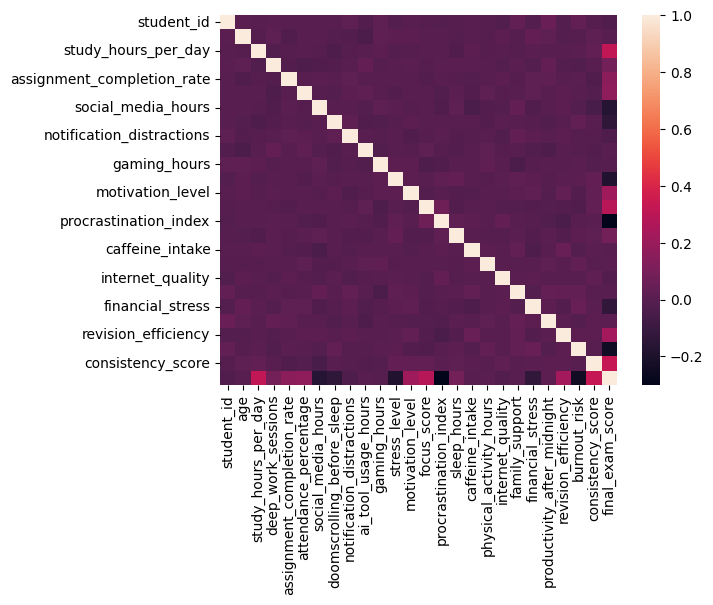

In [6]:
sns.heatmap(df.select_dtypes(include='number').corr())
plt.show()

In [7]:
#We must first drop irrelevant/leaky columns 
df = df.drop(columns=['student_id', 'performance_category'])

In [8]:
df.shape

(3000, 30)

In [9]:
df.isnull().sum()

age                             0
gender                          0
city_type                       0
study_hours_per_day             0
deep_work_sessions              0
assignment_completion_rate      0
attendance_percentage           0
social_media_hours             60
doomscrolling_before_sleep      0
notification_distractions       0
ai_tool_usage_hours             0
gaming_hours                    0
stress_level                    0
motivation_level                0
focus_score                    60
procrastination_index           0
mental_state                    0
sleep_hours                    60
caffeine_intake                 0
physical_activity_hours         0
internet_quality                0
family_support                  0
financial_stress                0
learning_style                  0
career_goal                     0
productivity_after_midnight     0
revision_efficiency             0
burnout_risk                    0
consistency_score               0
final_exam_sco

In [10]:
#Replace the missing values with the median of that column
df['social_media_hours'] = df['social_media_hours'].fillna(df['social_media_hours'].median())
df['focus_score'] = df['focus_score'].fillna(df['focus_score'].median())
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())
df.isnull().sum()

age                            0
gender                         0
city_type                      0
study_hours_per_day            0
deep_work_sessions             0
assignment_completion_rate     0
attendance_percentage          0
social_media_hours             0
doomscrolling_before_sleep     0
notification_distractions      0
ai_tool_usage_hours            0
gaming_hours                   0
stress_level                   0
motivation_level               0
focus_score                    0
procrastination_index          0
mental_state                   0
sleep_hours                    0
caffeine_intake                0
physical_activity_hours        0
internet_quality               0
family_support                 0
financial_stress               0
learning_style                 0
career_goal                    0
productivity_after_midnight    0
revision_efficiency            0
burnout_risk                   0
consistency_score              0
final_exam_score               0
dtype: int

In [11]:
#Turn all the text columns into numeric columns 
df = pd.get_dummies(df, drop_first=True)
print(df.shape)
print(df.dtypes.value_counts())

(3000, 38)
int64      18
bool       13
float64     7
Name: count, dtype: int64


In [12]:
#Change bool to int
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})
df.dtypes.value_counts()

int64      31
float64     7
Name: count, dtype: int64

In [13]:
#Finding which features are collrelated/should be used
corr = df.corr()['final_exam_score'].sort_values(ascending=False)
print(corr)

final_exam_score               1.000000
consistency_score              0.329144
study_hours_per_day            0.317229
focus_score                    0.284073
mental_state_Focused           0.254380
revision_efficiency            0.230729
motivation_level               0.209093
attendance_percentage          0.172020
assignment_completion_rate     0.159037
deep_work_sessions             0.086185
sleep_hours                    0.081309
career_goal_Medical            0.022628
productivity_after_midnight    0.014107
physical_activity_hours        0.008024
learning_style_Practical       0.006451
career_goal_Research           0.004496
caffeine_intake                0.000743
age                            0.000172
career_goal_Business          -0.001447
ai_tool_usage_hours           -0.003776
family_support                -0.004131
learning_style_Reading        -0.004306
mental_state_Distracted       -0.004923
city_type_Urban               -0.007104
gaming_hours                  -0.010042


In [14]:
#Filtering out the uncorrelated features
features = [
    # Positive predictors
    'consistency_score', 'study_hours_per_day', 'focus_score',
    'mental_state_Focused', 'revision_efficiency', 'motivation_level',
    'attendance_percentage', 'assignment_completion_rate',
    'deep_work_sessions', 'sleep_hours',
    
    # Negative predictors
    'procrastination_index', 'mental_state_Burnout', 'burnout_risk',
    'stress_level', 'social_media_hours', 'doomscrolling_before_sleep',
    'notification_distractions'
]

X = df[features]
y = df['final_exam_score']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,random_state=42)


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
fs = LinearRegression()

In [19]:
print(X_train.shape)
print(y_train.shape)

(2100, 17)
(2100,)


In [20]:
fs.fit(X_train, y_train)

LinearRegression()

In [21]:
fs.coef_

array([ 2.12728721,  3.99631391,  1.97703488,  7.57339278,  1.45653728,
        1.42557758,  0.20296493,  0.1954799 ,  0.82063421,  1.67406946,
       -1.97375717, -9.98092129, -1.5047632 , -1.27986773, -2.034706  ,
       -4.78433078, -0.01267607])

In [22]:
cdf = pd.DataFrame(fs.coef_, X.columns,columns=['Coef'] )
print(cdf)

                                Coef
consistency_score           2.127287
study_hours_per_day         3.996314
focus_score                 1.977035
mental_state_Focused        7.573393
revision_efficiency         1.456537
motivation_level            1.425578
attendance_percentage       0.202965
assignment_completion_rate  0.195480
deep_work_sessions          0.820634
sleep_hours                 1.674069
procrastination_index      -1.973757
mental_state_Burnout       -9.980921
burnout_risk               -1.504763
stress_level               -1.279868
social_media_hours         -2.034706
doomscrolling_before_sleep -4.784331
notification_distractions  -0.012676


In [23]:
predictions = fs.predict(X_test)
predictions

array([ 42.83267168,  61.39019205,  56.96700747,  44.4840785 ,
        39.67722789,  54.84440881,  76.81161078,  57.79130169,
        86.55963828,  51.78854777,  38.92858259,  71.98955661,
        48.91913205,  52.0552948 ,  47.73635505,  46.40954342,
        54.62448288,  32.90137794,  55.83186614,  93.3835666 ,
        60.43493666,  34.97915237,  66.01181589,  63.07366107,
        39.02583079,  69.72243426,  74.05947147,  69.87121262,
        49.80112696,  66.70566917,  41.96250858,  46.19667295,
        47.60547703,  42.04049808,  25.47249327,  56.700127  ,
        41.98847309,  47.19419081,  61.70839945,  14.41371189,
        82.58457478,  70.54111466,  65.32590308,  55.86687019,
        68.76866964,  41.19531498,  52.18432587,  29.03221344,
        48.16074169,  37.19985034,  29.71857891,  13.55568246,
        70.67561058,  81.89640316,  45.16649967,  32.18450073,
        81.20184315,  50.41571714,  62.0183641 ,  54.34888232,
        53.63222331,  56.96048973,  43.21755711,  62.32

Text(0.5, 1.0, 'Evaluation of lin reg model')

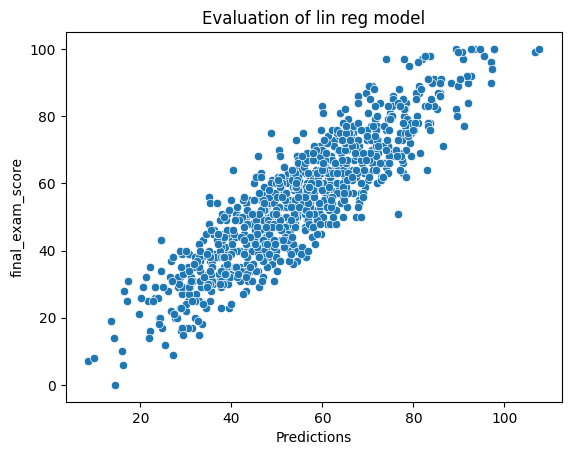

In [24]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel('Predictions')
plt.title("Evaluation of lin reg model")

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [26]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

MAE:  6.74
RMSE: 8.25
R²:   0.80


In [27]:
#Residuals

residuals = y_test - predictions 

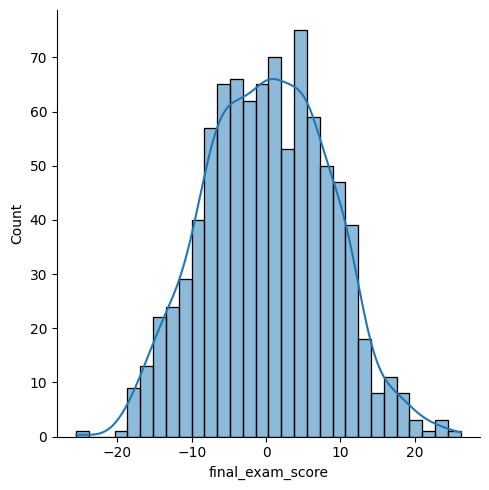

In [28]:
sns.displot(residuals,bins = 30, kde = True)

In [29]:
import pylab 
import scipy.stats as stats 

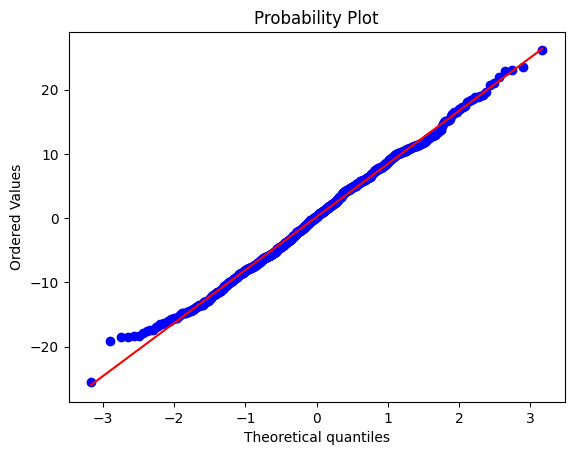

In [30]:
stats.probplot(residuals, dist="norm", plot = pylab)
pylab.show()

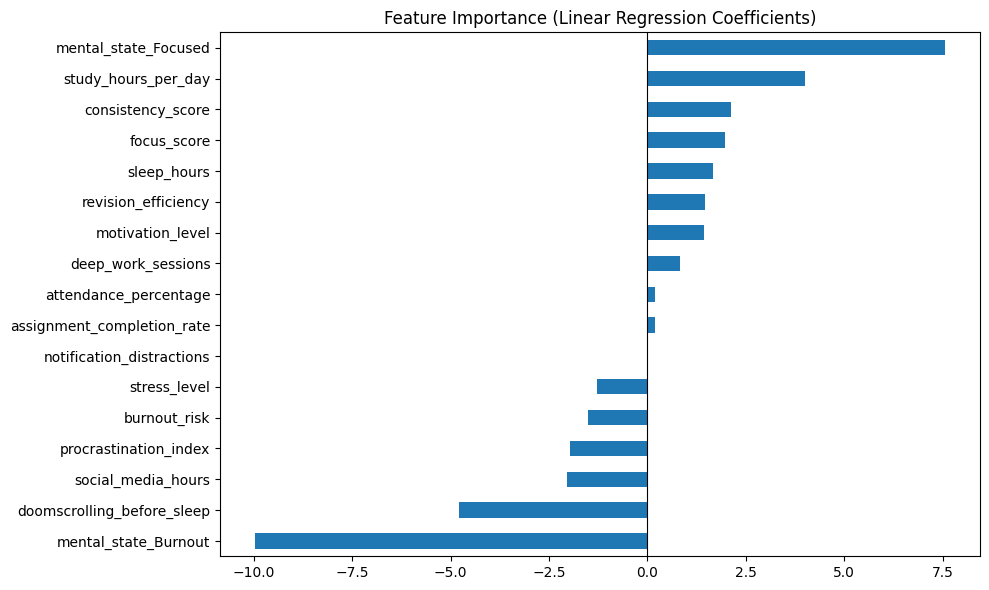

In [31]:
#To see which columns have the most impact 
coefficients = pd.Series(fs.coef_, index=features)
coefficients.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [32]:
#Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(fs, X, y, cv=5, scoring='r2')

print(f"R² per fold: {scores.round(2)}")
print(f"Mean R²:     {scores.mean():.2f}")
print(f"Std Dev:     {scores.std():.2f}")

R² per fold: [0.79 0.78 0.81 0.76 0.8 ]
Mean R²:     0.79
Std Dev:     0.02


In [33]:
#Regularization
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge_scores = cross_val_score(ridge, X, y, cv=5, scoring='r2')

# Lasso
lasso = Lasso(alpha=1.0)
lasso_scores = cross_val_score(lasso, X, y, cv=5, scoring='r2')

print(f"Baseline R²: 0.79")
print(f"Ridge R²:    {ridge_scores.mean():.2f} ± {ridge_scores.std():.2f}")
print(f"Lasso R²:    {lasso_scores.mean():.2f} ± {lasso_scores.std():.2f}")

Baseline R²: 0.79
Ridge R²:    0.79 ± 0.02
Lasso R²:    0.75 ± 0.02


This appears to be the best model for this dataset. To improve it further, one could perform additional feature engineering, such as combining columns, removing less correlated features, or creating new variables, and then compare the results.